In [1]:
# Step 0: Environment Setup & Libraries

import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score,
 confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
# Global Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("Liberaries Imported Sucessfully")

Liberaries Imported Sucessfully


In [2]:
# =============================================
# Step 1: Download & Load Spam Dataset
# =============================================
print("STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE")
print("=" * 45)

url_direct = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    # Download dataset
    urllib.request.urlretrieve(url_direct,"sms_data.tsv")
    print("Dataset downloaded successfully from GitHub!")
    # Load dataset
    df = pd.read_csv("sms_data.tsv",sep="\t",header=None,names=["label", "message"])
except Exception as e:
    print("Primary source failed.")
    print("Loading backup dataset...")
    # Small backup spam dataset
    data = {
        "label": ["ham","ham","spam","spam","ham","spam"],
        "message": ["Hey, are you coming to class today?",
                    "Can you send me the project file?",
                    "Congratulations! You won a free lottery prize.",
                    "Win money now! Click this link.",
                    "Let's meet tomorrow morning.",
                    "You have been selected for a free gift." ]}
    df = pd.DataFrame(data)

# =============================================
# Dataset Exploration
# =============================================

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Messages:")
print(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts())

# Percentage of spam messages
spam_percentage = (df["label"].value_counts(normalize=True).get("spam", 0)* 100)
print(f"\nSpam Percentage: {spam_percentage:.2f}%")

STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE
Dataset downloaded successfully from GitHub!

Dataset Shape:
(5572, 2)

First 5 Messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam Percentage: 13.41%


STEP 2: VISUALIZING SPAM VS HAM PATTERNS


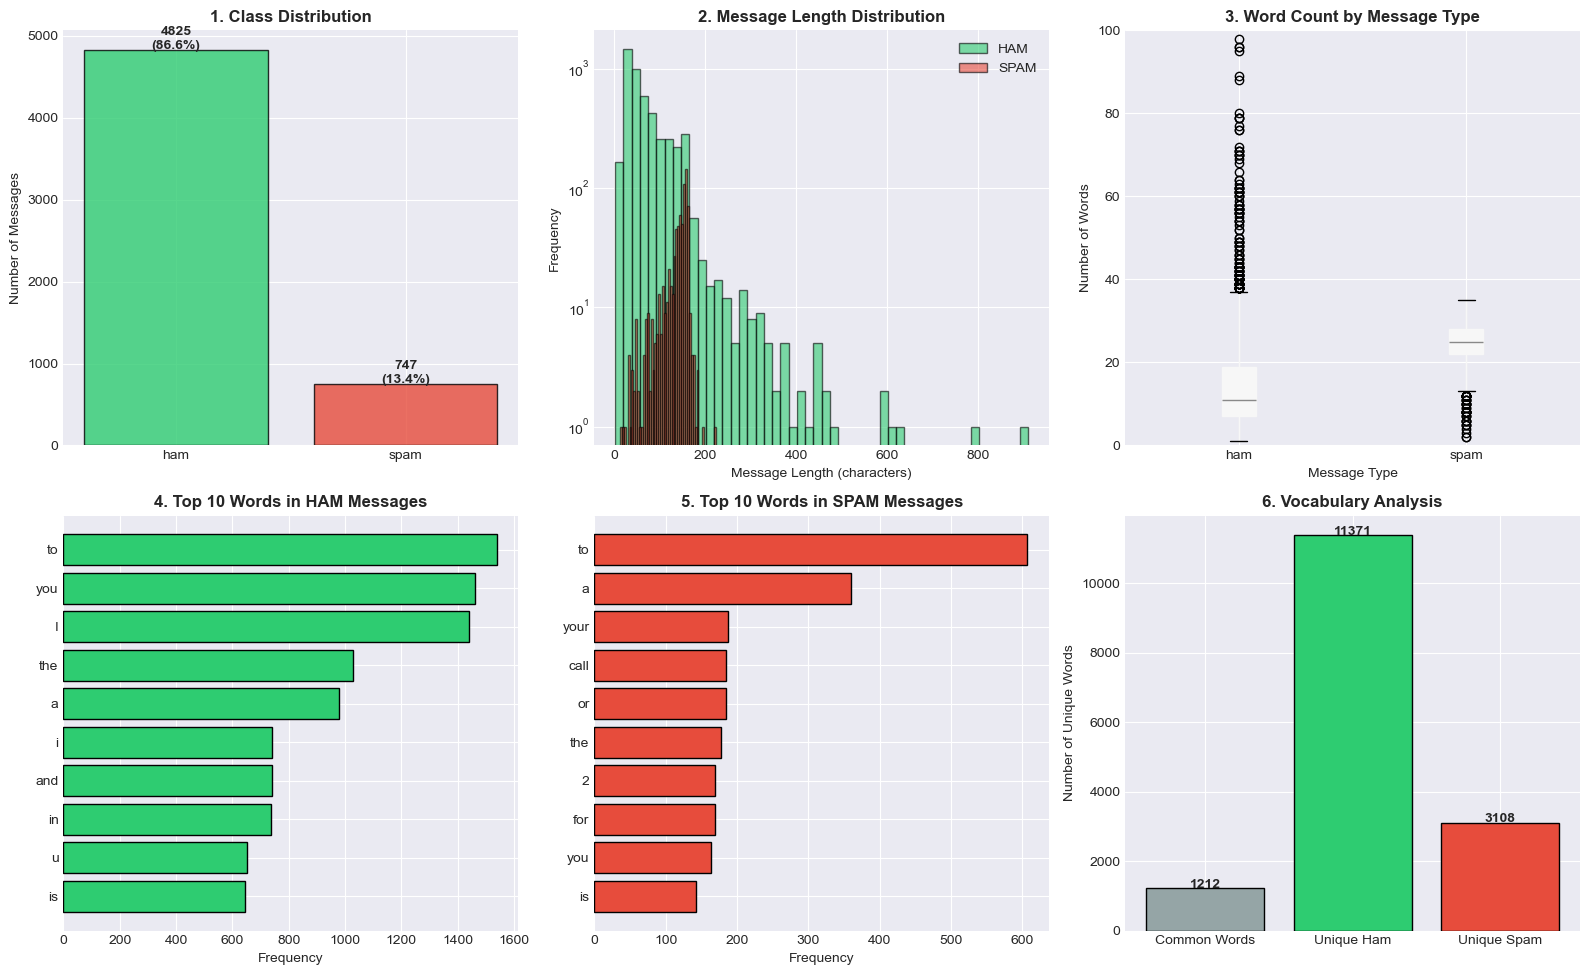

In [3]:
# =============================================
# STEP 2: VISUALIZING SPAM VS HAM PATTERNS
# =============================================
print("STEP 2: VISUALIZING SPAM VS HAM PATTERNS")
print("=" * 45)
from collections import Counter

# Create figure
fig, axes = plt.subplots(2, 3,figsize=(16, 10))
fig.suptitle('SMS/Email Spam Classification - Data Analysis',fontsize=16,fontweight='bold')

# =============================================
# 1. Class Distribution
# =============================================

ax1 = axes[0, 0]
class_counts = df['label'].value_counts()
colors_class = ['#2ecc71', '#e74c3c']
bars = ax1.bar(class_counts.index,class_counts.values,color=colors_class,edgecolor='black',alpha=0.8)
ax1.set_title('1. Class Distribution',fontsize=12,fontweight='bold')
ax1.set_ylabel('Number of Messages')
for bar, count in zip(bars, class_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center',
        fontweight='bold' )

# =============================================
# 2. Message Length Distribution
# =============================================
ax2 = axes[0, 1]
df['message_length'] = df['message'].str.len()
for label, color in zip(['ham', 'spam'],['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['message_length']
    ax2.hist(
        subset,bins=50,alpha=0.6,
        label=label.upper(),
        color=color,edgecolor='black')
ax2.set_title('2. Message Length Distribution',fontsize=12,fontweight='bold')
ax2.set_xlabel('Message Length (characters)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.set_yscale('log')

# =============================================
# 3. Word Count Distribution
# =============================================
ax3 = axes[0, 2]
df['word_count'] = (df['message'].str.split().str.len())
df.boxplot(column='word_count',by='label',ax=ax3,patch_artist=True)
ax3.set_title('3. Word Count by Message Type',fontsize=12,fontweight='bold')
ax3.set_xlabel('Message Type')
ax3.set_ylabel('Number of Words')
ax3.set_ylim(0, 100)
plt.suptitle("")

# =============================================
# 4. Top Words in HAM Messages
# =============================================
ax4 = axes[1, 0]
ham_words = (' '.join(df[df['label']=='ham']['message']).split())
ham_top10 = Counter(ham_words).most_common(10)
words_ham, counts_ham = zip(*ham_top10)
ax4.barh(words_ham,counts_ham,color='#2ecc71',edgecolor='black')
ax4.set_title('4. Top 10 Words in HAM Messages',fontsize=12,fontweight='bold')
ax4.set_xlabel('Frequency')
ax4.invert_yaxis()

# =============================================
# 5. Top Words in SPAM Messages
# =============================================

ax5 = axes[1, 1]
spam_words = (' '.join(df[df['label']=='spam']['message']).split())
spam_top10 = Counter(spam_words).most_common(10)
words_spam, counts_spam = zip(*spam_top10)
ax5.barh(words_spam,counts_spam,color='#e74c3c',edgecolor='black')
ax5.set_title('5. Top 10 Words in SPAM Messages',fontsize=12,fontweight='bold')
ax5.set_xlabel('Frequency')
ax5.invert_yaxis()

# =============================================
# 6. Vocabulary Analysis
# =============================================
ax6 = axes[1, 2]
ham_set = set(' '.join(df[df['label']=='ham']['message']).split())
spam_set = set(' '.join(df[df['label']=='spam']['message']).split())
common_words = len(
ham_set.intersection(spam_set))
unique_ham = len(ham_set - spam_set)
unique_spam = len(spam_set - ham_set)
x_labels = ['Common Words','Unique Ham','Unique Spam']
y_values = [common_words,unique_ham,unique_spam]
bars = ax6.bar(x_labels,y_values,color=['#95a5a6','#2ecc71','#e74c3c'],edgecolor='black')
ax6.set_title('6. Vocabulary Analysis',fontsize=12,fontweight='bold')
ax6.set_ylabel('Number of Unique Words')
for bar, value in zip(bars, y_values):
    ax6.text(
        bar.get_x()+bar.get_width()/2,
        value+20,
        str(value),
        ha='center',
        fontweight='bold'
    )

# Final display
plt.tight_layout()
plt.show()

In [4]:
# ==========================================================
# STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING
# ==========================================================

print("=" * 45)
print("STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING")
print("=" * 45)

# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------
# Create Target Variable
# Binary Encoding:
# Spam = 1
# Ham = 0
# ----------------------------------------------------------
y = (df["label"] == "spam").astype(int)

# Input Text Feature
X_text = df["message"]

# ----------------------------------------------------------
# TF-IDF Vectorization
# ----------------------------------------------------------
vectorizer = TfidfVectorizer(
    max_features=3000,      # Keep top 3000 important words
    stop_words="english",   # Remove common English stop words
    ngram_range=(1, 2),     # Use unigrams and bigrams
    lowercase=True,         # Convert all text to lowercase
    max_df=0.80,            # Ignore words appearing in >80% of documents
    min_df=2                # Ignore words appearing in fewer than 2 documents
)

# Convert text into numerical features
X = vectorizer.fit_transform(X_text)

# ----------------------------------------------------------
# Display TF-IDF Information
# ----------------------------------------------------------
print(f"Feature Matrix Shape : {X.shape}")
print(f"Number of Features   : {len(vectorizer.get_feature_names_out())}")
print("\nFirst 15 Features:")
print(vectorizer.get_feature_names_out()[:15])

# ----------------------------------------------------------
# Split Dataset
# 80% Training
# 20% Testing
# Stratify keeps the same spam/ham ratio
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ----------------------------------------------------------
# Display Dataset Information
# ----------------------------------------------------------
print("\nDataset Split")
print("-" * 30)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Training Features: {X_train.shape[1]}")
print(f"Testing Features : {X_test.shape[1]}")

# ----------------------------------------------------------
# Baseline Accuracy
# ----------------------------------------------------------
baseline_accuracy = y.value_counts(normalize=True).max() * 100

print("\nClass Distribution")
print("-" * 30)
print(y.value_counts())

print(f"\nBaseline Accuracy : {baseline_accuracy:.2f}%")

STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING
Feature Matrix Shape : (5572, 3000)
Number of Features   : 3000

First 15 Features:
['00' '00 sub' '000' '000 bonus' '000 cash' '02' '03' '03 2nd' '04' '05'
 '06' '06 03' '0800' '0800 542' '08000839402']

Dataset Split
------------------------------
Training Samples : 4457
Testing Samples  : 1115
Training Features: 3000
Testing Features : 3000

Class Distribution
------------------------------
label
0    4825
1     747
Name: count, dtype: int64

Baseline Accuracy : 86.59%


In [5]:
# ==========================================================
# STEP 4: TRAINING THE NAIVE BAYES CLASSIFIER
# ==========================================================

print("=" * 45)
print("STEP 4: TRAINING THE NAIVE BAYES CLASSIFIER")
print("=" * 45)

# Import the classifier
from sklearn.naive_bayes import MultinomialNB

# ----------------------------------------------------------
# Create the Multinomial Naive Bayes Model
# alpha = Laplace smoothing parameter
# Smaller alpha = Less smoothing
# ----------------------------------------------------------
model = MultinomialNB(alpha=0.5)

# ----------------------------------------------------------
# Train the Model
# ----------------------------------------------------------
model.fit(X_train, y_train)

# ----------------------------------------------------------
# Display Training Information
# ----------------------------------------------------------
print("✅ Model trained successfully!")

print("\nModel Information")
print("-" * 30)
print(f"Algorithm           : Multinomial Naive Bayes")
print(f"Smoothing (alpha)   : {model.alpha}")
print(f"Training Samples    : {X_train.shape[0]}")
print(f"Number of Features  : {X_train.shape[1]}")
print(f"Number of Classes   : {len(model.classes_)}")
print(f"Classes             : {model.classes_}")

print("\nTraining completed successfully!")

STEP 4: TRAINING THE NAIVE BAYES CLASSIFIER
✅ Model trained successfully!

Model Information
------------------------------
Algorithm           : Multinomial Naive Bayes
Smoothing (alpha)   : 0.5
Training Samples    : 4457
Number of Features  : 3000
Number of Classes   : 2
Classes             : [0 1]

Training completed successfully!


STEP 5: GENERATING LEARNING CURVES


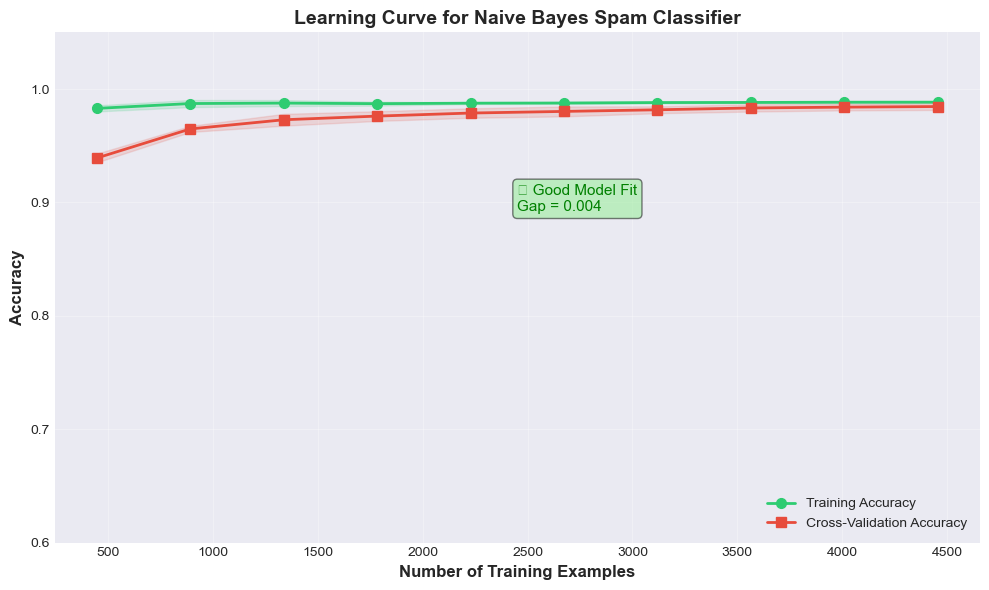


Learning Curve Summary
-----------------------------------
Final Training Accuracy         : 0.9884
Final Cross-Validation Accuracy : 0.9846
Generalization Gap              : 0.0039
Model Status : Good Generalization


In [6]:
# ==========================================================
# STEP 5: GENERATING LEARNING CURVE ANALYSIS
# ==========================================================

print("=" * 45)
print("STEP 5: GENERATING LEARNING CURVES")
print("=" * 45)
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
# ----------------------------------------------------------
# Generate Learning Curve Data
# ----------------------------------------------------------
train_sizes, train_scores, test_scores = learning_curve(
    estimator=model,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# ----------------------------------------------------------
# Calculate Mean and Standard Deviation
# ----------------------------------------------------------
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# ----------------------------------------------------------
# Plot Learning Curves
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
# Training Curve
ax.fill_between(
    train_sizes,train_mean - train_std,
    train_mean + train_std,alpha=0.15,
    color="#2ecc71")

# Validation Curve
ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.15,
    color="#e74c3c"
)

# Plot Mean Accuracy
ax.plot(
    train_sizes,
    train_mean,
    "o-",
    color="#2ecc71",
    linewidth=2,
    markersize=7,
    label="Training Accuracy"
)

ax.plot(
    train_sizes,
    test_mean,
    "s-",
    color="#e74c3c",
    linewidth=2,
    markersize=7,
    label="Cross-Validation Accuracy"
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------
ax.set_title(
    "Learning Curve for Naive Bayes Spam Classifier",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Number of Training Examples",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontsize=12,
    fontweight="bold"
)

ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_ylim(0.60, 1.05)

# ----------------------------------------------------------
# Detect Overfitting
# ----------------------------------------------------------
gap = train_mean[-1] - test_mean[-1]

if gap > 0.10:
    ax.text(
        0.50,
        0.65,
        f"⚠ Overfitting Detected\nGap = {gap:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        color="red",
        bbox=dict(
            boxstyle="round",
            facecolor="yellow",
            alpha=0.5
        )
    )
else:
    ax.text(
        0.50,
        0.65,
        f"✓ Good Model Fit\nGap = {gap:.3f}",
        transform=ax.transAxes,
        fontsize=11,
        color="green",
        bbox=dict(
            boxstyle="round",
            facecolor="lightgreen",
            alpha=0.5
        )
    )

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Print Summary
# ----------------------------------------------------------
print("\nLearning Curve Summary")
print("-" * 35)
print(f"Final Training Accuracy         : {train_mean[-1]:.4f}")
print(f"Final Cross-Validation Accuracy : {test_mean[-1]:.4f}")
print(f"Generalization Gap              : {gap:.4f}")

if gap > 0.10:
    print("Model Status : Overfitting")
else:
    print("Model Status : Good Generalization")

In [7]:
# ==========================================================
# STEP 6: QUANTITATIVE MODEL EVALUATION
# ==========================================================
print("=" * 45)
print("STEP 6: QUANTITATIVE MODEL EVALUATION")
print("=" * 45)
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,precision_score,
    recall_score,f1_score,
    classification_report,confusion_matrix)

# ----------------------------------------------------------
# Generate Predictions
# ----------------------------------------------------------
# Predicted class labels
y_pred = model.predict(X_test)
# Probability of Spam class
y_pred_proba = model.predict_proba(X_test)[:, 1]
# ----------------------------------------------------------
# Calculate Classification Metrics
# ----------------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
# ----------------------------------------------------------
# Display Evaluation Results
# ----------------------------------------------------------
print("\nCLASSIFICATION METRICS")
print("-" * 40)
print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score  : {f1:.4f} ({f1 * 100:.2f}%)")

# ----------------------------------------------------------
# Classification Report
# ----------------------------------------------------------
print("\nDETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test,y_pred,target_names=["HAM (0)","SPAM (1)"]))


# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------
print("\nCONFUSION MATRIX")
print("=" * 40)
cm = confusion_matrix(y_test, y_pred)
print(cm)

STEP 6: QUANTITATIVE MODEL EVALUATION

CLASSIFICATION METRICS
----------------------------------------
Accuracy  : 0.9821 (98.21%)
Precision : 0.9924 (99.24%)
Recall    : 0.8725 (87.25%)
F1-Score  : 0.9286 (92.86%)

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     HAM (0)       0.98      1.00      0.99       966
    SPAM (1)       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


CONFUSION MATRIX
[[965   1]
 [ 19 130]]


STEP 7: COMPREHENSIVE VISUAL EVALUATION


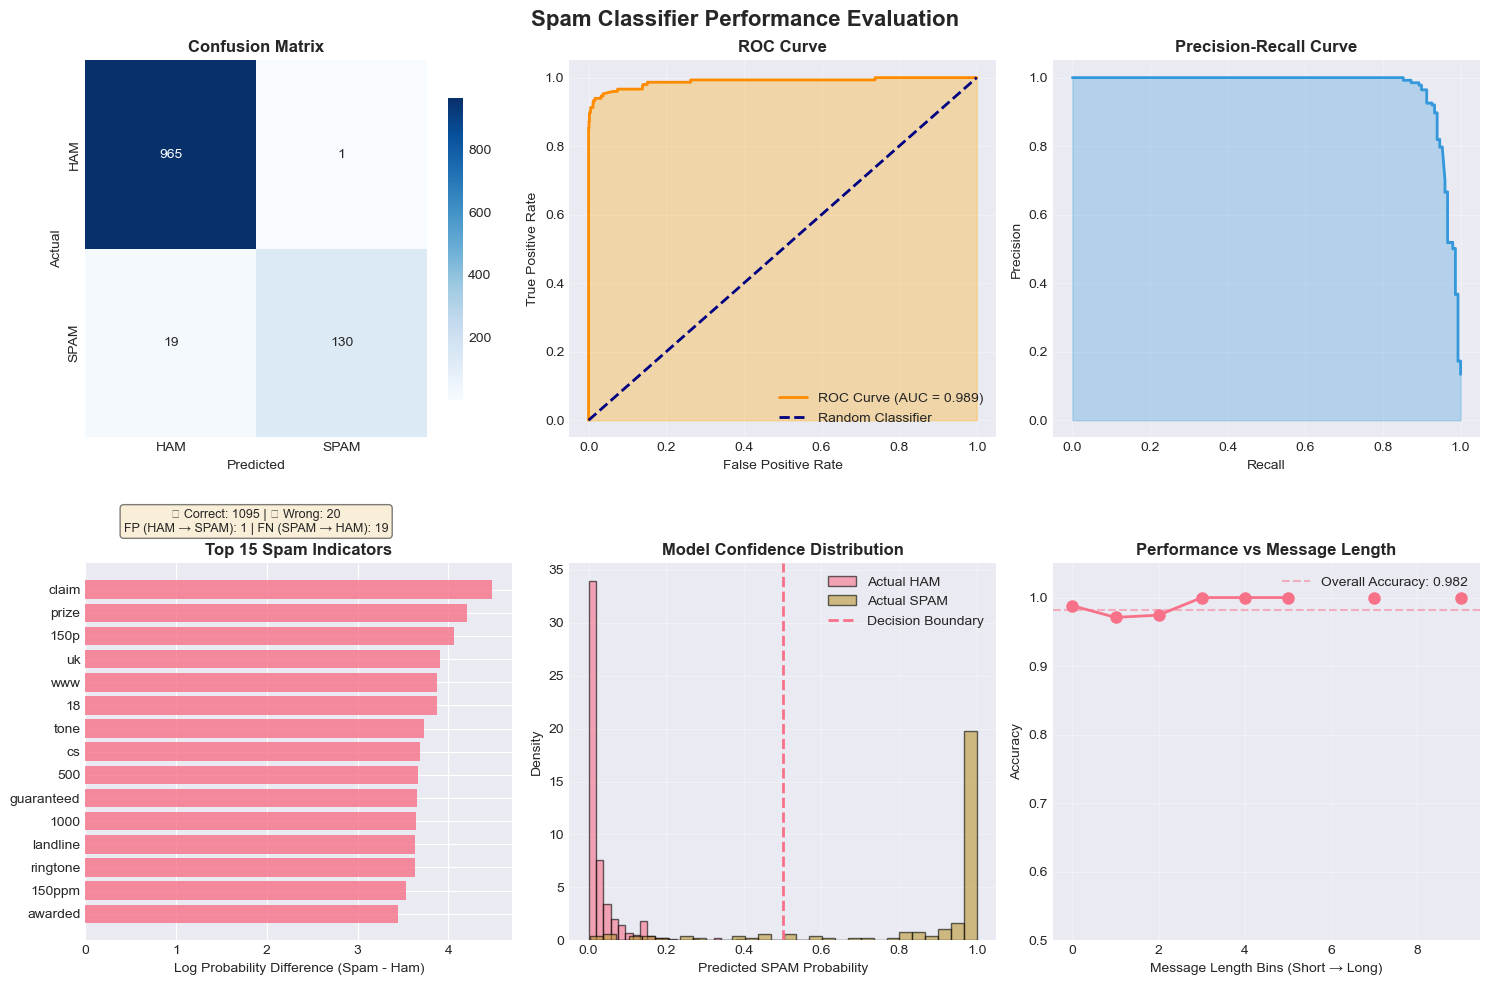

In [8]:
# ==========================================================
# STEP 7: COMPREHENSIVE VISUAL EVALUATION
# ==========================================================

print("=" * 45)
print("STEP 7: COMPREHENSIVE VISUAL EVALUATION")
print("=" * 45)

# Import required libraries
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve
)

# Create subplot layout
fig, axes = plt.subplots(2,3,figsize=(15, 10))
fig.suptitle(
    "Spam Classifier Performance Evaluation",
    fontsize=16,fontweight="bold")
# ==========================================================
# 1. CONFUSION MATRIX
# ==========================================================

ax1 = axes[0, 0]
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(
    cm,annot=True,fmt="d",cmap="Blues",
    ax=ax1,xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"],cbar_kws={"shrink": 0.8})
ax1.set_title(
    "Confusion Matrix",
    fontsize=12,
    fontweight="bold"
)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")
tn, fp, fn, tp = cm.ravel()
ax1.text(
    0.5,
    -0.25,
    f"✓ Correct: {tn+tp} | ✗ Wrong: {fp+fn}\n"
    f"FP (HAM → SPAM): {fp} | FN (SPAM → HAM): {fn}",
    transform=ax1.transAxes,
    ha="center",
    fontsize=9,
    bbox=dict(
        boxstyle="round",facecolor="wheat",alpha=0.5
    ))
# ==========================================================
# 2. ROC CURVE
# ==========================================================
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test,y_pred_proba)
roc_auc = auc(fpr,tpr)
ax2.plot(fpr,tpr,color="darkorange",linewidth=2,label=f"ROC Curve (AUC = {roc_auc:.3f})")

ax2.plot(
    [0, 1],[0, 1],color="navy",linestyle="--",
    linewidth=2,label="Random Classifier")
ax2.fill_between(fpr,tpr,alpha=0.3,color="orange")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve",fontsize=12,fontweight="bold")
ax2.legend(loc="lower right")
ax2.grid(True,alpha=0.3)


# ==========================================================
# 3. PRECISION-RECALL CURVE
# ==========================================================

ax3 = axes[0, 2]
precision_curve, recall_curve, _ = precision_recall_curve(y_test,y_pred_proba)
ax3.plot(
    recall_curve,precision_curve,
    color="#3498db",linewidth=2)
ax3.fill_between(
    recall_curve,precision_curve,
    alpha=0.3,color="#3498db"
)

ax3.set_xlabel("Recall")
ax3.set_ylabel("Precision")

ax3.set_title(
    "Precision-Recall Curve",
    fontsize=12,
    fontweight="bold"
)

ax3.grid(
    True,
    alpha=0.3
)


# ==========================================================
# 4. TOP SPAM PREDICTIVE FEATURES
# ==========================================================
ax4 = axes[1, 0]
feature_names = vectorizer.get_feature_names_out()
feature_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance":
            model.feature_log_prob_[1]
            -
            model.feature_log_prob_[0]
    }
)

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).head(15)
ax4.barh(
    feature_importance["feature"],
    feature_importance["importance"],
    alpha=0.8)
ax4.set_xlabel("Log Probability Difference (Spam - Ham)")
ax4.set_title("Top 15 Spam Indicators",fontsize=12,fontweight="bold")
ax4.invert_yaxis()

# ==========================================================
# 5. PREDICTION CONFIDENCE DISTRIBUTION
# ==========================================================
ax5 = axes[1, 1]
spam_proba = y_pred_proba[y_test == 1]
ham_proba = y_pred_proba[y_test == 0]
ax5.hist(ham_proba,bins=30,alpha=0.6,label="Actual HAM",edgecolor="black",density=True
)

ax5.hist(
    spam_proba,
    bins=30,
    alpha=0.6,
    label="Actual SPAM",
    edgecolor="black",
    density=True
)


ax5.axvline(
    x=0.5,
    linestyle="--",
    linewidth=2,
    label="Decision Boundary"
)


ax5.set_xlabel(
    "Predicted SPAM Probability"
)

ax5.set_ylabel(
    "Density"
)

ax5.set_title(
    "Model Confidence Distribution",
    fontsize=12,
    fontweight="bold"
)

ax5.legend()

ax5.grid(
    True,
    alpha=0.3
)



# ==========================================================
# 6. MODEL PERFORMANCE VS MESSAGE LENGTH
# ==========================================================

ax6 = axes[1, 2]


test_indices = y_test.index

test_lengths = df.loc[
    test_indices,
    "message_length"
].values


df_test = pd.DataFrame(
    {
        "true_label": y_test.values,
        "pred_label": y_pred,
        "length": test_lengths
    }
)


df_test["length_bin"] = pd.cut(
    df_test["length"],
    bins=10
)


accuracy_by_length = (
    df_test
    .groupby("length_bin", observed=False)
    .apply(
        lambda g:
        accuracy_score(
            g["true_label"],
            g["pred_label"]
        )
    )
)


ax6.plot(
    range(len(accuracy_by_length)),
    accuracy_by_length.values,
    "o-",
    linewidth=2,
    markersize=8
)


ax6.set_xlabel(
    "Message Length Bins (Short → Long)"
)

ax6.set_ylabel(
    "Accuracy"
)

ax6.set_title(
    "Performance vs Message Length",
    fontsize=12,
    fontweight="bold"
)

ax6.set_ylim(
    [0.5, 1.05]
)

ax6.grid(
    True,
    alpha=0.3
)


ax6.axhline(
    y=accuracy,
    linestyle="--",
    alpha=0.5,
    label=f"Overall Accuracy: {accuracy:.3f}"
)

ax6.legend()


# ==========================================================
# DISPLAY ALL PLOTS
# ==========================================================

plt.tight_layout()
plt.show()

In [9]:
# ==========================================================
# STEP 8: LIVE SPAM DETECTION DEMO
# ==========================================================
print("=" * 45)
print("STEP 8: LIVE SPAM DETECTION DEMO")
print("=" * 45)
# Sample messages for testing
test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: bit.ly/xxx",
    "The meeting has been rescheduled to 3pm. Thanks!",
    "FREE entry to win $1000 gift card! Text WIN to 12345",
    "Don't forget to submit your report by Friday."
]


# ----------------------------------------------------------
# Predict each message
# ----------------------------------------------------------
for msg in test_messages:
    # Convert text into TF-IDF features
    msg_vectorized = vectorizer.transform([msg])
    # Predict class
    prediction = model.predict(msg_vectorized)[0]
    # Get spam probability
    probability = model.predict_proba(msg_vectorized)[0][1]
    # Convert prediction to readable label
    label_str = "SPAM" if prediction == 1 else "HAM"
    # Calculate confidence
    confidence = (
        probability
        if prediction == 1
        else 1 - probability)
    # Display result
    print("\nMessage:")
    print(msg)
    print(
        f"Result: {label_str} "
        f"(Confidence: {confidence:.2%})" )
    print("-" * 60)
# ----------------------------------------------------------
# Cleanup Temporary Files
# ----------------------------------------------------------
import os
if os.path.exists("sms_data.tsv"):
    os.remove("sms_data.tsv")
print("\n[INFO] Cleaned up temporary storage files.")

STEP 8: LIVE SPAM DETECTION DEMO

Message:
Congratulations! You've won a free iPhone! Click here to claim now!
Result: SPAM (Confidence: 91.93%)
------------------------------------------------------------

Message:
Hey, are we still meeting for lunch tomorrow?
Result: HAM (Confidence: 99.82%)
------------------------------------------------------------

Message:
URGENT: Your account has been compromised. Verify now: bit.ly/xxx
Result: HAM (Confidence: 83.12%)
------------------------------------------------------------

Message:
The meeting has been rescheduled to 3pm. Thanks!
Result: HAM (Confidence: 98.71%)
------------------------------------------------------------

Message:
FREE entry to win $1000 gift card! Text WIN to 12345
Result: SPAM (Confidence: 97.01%)
------------------------------------------------------------

Message:
Don't forget to submit your report by Friday.
Result: HAM (Confidence: 98.03%)
------------------------------------------------------------

[INFO] Clean